# MNIST VAE：從訓練到生成

這份 Notebook 會帶你實作一個可以訓練的 **Variational AutoEncoder, VAE**。

核心觀念：

- 普通 AutoEncoder：`image → encoder → z → decoder → reconstruction`
- VAE：`image → encoder → mu, logvar → sample z → decoder → reconstruction`

也就是說，VAE 的 encoder 不是直接輸出一個固定 latent，而是輸出 latent 分布的參數。

## 1. 匯入套件與基本設定

這裡會自動偵測 GPU。如果你有 NVIDIA GPU 並且 PyTorch CUDA 版本正確，會使用 `cuda`。

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 128
epochs = 20
learning_rate = 1e-3
latent_dim = 20

os.makedirs("results/reconstruction", exist_ok=True)
os.makedirs("results/sample", exist_ok=True)

Using device: cuda


## 2. 載入 MNIST Dataset

MNIST 圖片大小是：

```text
[1, 28, 28]
```

也就是灰階圖片，1 個 channel，高寬都是 28。

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

x, y = next(iter(train_loader))
print("x shape:", x.shape)
print("y shape:", y.shape)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:22<00:00, 445kB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.01MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 1.47MB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

x shape: torch.Size([128, 1, 28, 28])
y shape: torch.Size([128])


## 3. 看一下 MNIST 長什麼樣子

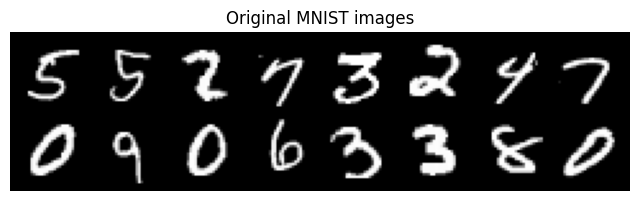

In [4]:
def show_images(images, nrow=8, title=None):
    grid = make_grid(images.cpu(), nrow=nrow, padding=2)
    plt.figure(figsize=(8, 4))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()

show_images(x[:16], nrow=8, title="Original MNIST images")

## 4. 建立 VAE Model

這個版本用最經典的 MLP VAE：

```text
image [1, 28, 28]
→ flatten [784]
→ hidden [400]
→ mu [latent_dim]
→ logvar [latent_dim]
→ sample z [latent_dim]
→ reconstruction [784]
```

注意：encoder 不是輸出 `z`，而是輸出 `mu` 和 `logvar`。

In [5]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        # x: [batch, 784]
        # return mu/logvar: [batch, latent_dim]
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # z = mu + std * eps, eps ~ N(0, 1)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        h = F.relu(self.fc2(z))
        x_recon = torch.sigmoid(self.fc3(h))
        return x_recon

    def forward(self, x):
        x = x.view(x.size(0), -1)  # [batch, 784]
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
)


## 5. 檢查 mu、logvar、z 的形狀

這格很重要，因為它能直接看到 VAE 的核心：

```text
input image → mu, logvar → sample z
```

In [6]:
model.eval()
with torch.no_grad():
    sample_x, _ = next(iter(train_loader))
    sample_x = sample_x.to(device)

    flat_x = sample_x.view(sample_x.size(0), -1)
    mu, logvar = model.encode(flat_x)
    z = model.reparameterize(mu, logvar)
    x_recon = model.decode(z)

print("sample_x shape:", sample_x.shape)
print("flat_x shape:  ", flat_x.shape)
print("mu shape:      ", mu.shape)
print("logvar shape:  ", logvar.shape)
print("z shape:       ", z.shape)
print("x_recon shape: ", x_recon.shape)

sample_x shape: torch.Size([128, 1, 28, 28])
flat_x shape:   torch.Size([128, 784])
mu shape:       torch.Size([128, 20])
logvar shape:   torch.Size([128, 20])
z shape:        torch.Size([128, 20])
x_recon shape:  torch.Size([128, 784])


## 6. VAE Loss

VAE 的 loss 由兩部分組成：

### Reconstruction Loss

希望重建圖接近原圖。

### KL Loss

希望 encoder 產生的分布 `q(z|x)` 不要太亂，盡量接近標準常態分布：

```text
N(0, 1)
```

這樣 latent space 會比較平滑，也比較容易從隨機 latent 生成圖片。

In [7]:
def vae_loss(x_recon, x, mu, logvar):
    x = x.view(x.size(0), -1)

    recon_loss = F.binary_cross_entropy(
        x_recon,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

## 7. 訓練 VAE

訓練過程中每個 epoch 會存兩種圖片：

- `results/reconstruction/`：原圖與重建圖比較
- `results/sample/`：從標準常態分布隨機抽 z 生成的新數字

In [8]:
history = {
    "loss": [],
    "recon_loss": [],
    "kl_loss": [],
}

for epoch in range(1, epochs + 1):
    model.train()

    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(device)

        x_recon, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(x_recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()

    avg_loss = total_loss / len(train_dataset)
    avg_recon_loss = total_recon_loss / len(train_dataset)
    avg_kl_loss = total_kl_loss / len(train_dataset)

    history["loss"].append(avg_loss)
    history["recon_loss"].append(avg_recon_loss)
    history["kl_loss"].append(avg_kl_loss)

    print(
        f"Epoch [{epoch}/{epochs}] "
        f"Loss: {avg_loss:.4f} "
        f"Recon: {avg_recon_loss:.4f} "
        f"KL: {avg_kl_loss:.4f}"
    )

    model.eval()
    with torch.no_grad():
        sample_x, _ = next(iter(train_loader))
        sample_x = sample_x.to(device)
        x_recon, _, _ = model(sample_x)

        comparison = torch.cat([
            sample_x[:8],
            x_recon.view(-1, 1, 28, 28)[:8]
        ])

        save_image(
            comparison.cpu(),
            f"results/reconstruction/reconstruction_epoch_{epoch}.png",
            nrow=8
        )

        z = torch.randn(64, latent_dim).to(device)
        sample = model.decode(z)

        save_image(
            sample.view(64, 1, 28, 28).cpu(),
            f"results/sample/sample_epoch_{epoch}.png",
            nrow=8
        )

print("Training finished.")

Epoch [1/20] Loss: 164.9355 Recon: 149.5648 KL: 15.3707
Epoch [2/20] Loss: 121.7573 Recon: 99.5633 KL: 22.1940
Epoch [3/20] Loss: 114.7365 Recon: 90.8866 KL: 23.8499
Epoch [4/20] Loss: 111.7346 Recon: 87.2740 KL: 24.4606
Epoch [5/20] Loss: 109.9051 Recon: 85.1471 KL: 24.7580
Epoch [6/20] Loss: 108.7002 Recon: 83.7857 KL: 24.9146
Epoch [7/20] Loss: 107.8325 Recon: 82.8268 KL: 25.0057
Epoch [8/20] Loss: 107.1454 Recon: 82.0460 KL: 25.0995
Epoch [9/20] Loss: 106.6522 Recon: 81.4437 KL: 25.2085
Epoch [10/20] Loss: 106.1764 Recon: 80.9641 KL: 25.2123
Epoch [11/20] Loss: 105.8828 Recon: 80.6173 KL: 25.2656
Epoch [12/20] Loss: 105.5276 Recon: 80.2170 KL: 25.3106
Epoch [13/20] Loss: 105.2996 Recon: 79.9335 KL: 25.3662
Epoch [14/20] Loss: 104.9939 Recon: 79.6486 KL: 25.3453
Epoch [15/20] Loss: 104.7596 Recon: 79.3947 KL: 25.3650
Epoch [16/20] Loss: 104.5799 Recon: 79.1819 KL: 25.3980
Epoch [17/20] Loss: 104.4253 Recon: 78.9855 KL: 25.4399
Epoch [18/20] Loss: 104.2367 Recon: 78.8058 KL: 25.4309


## 8. 畫出 Loss 曲線

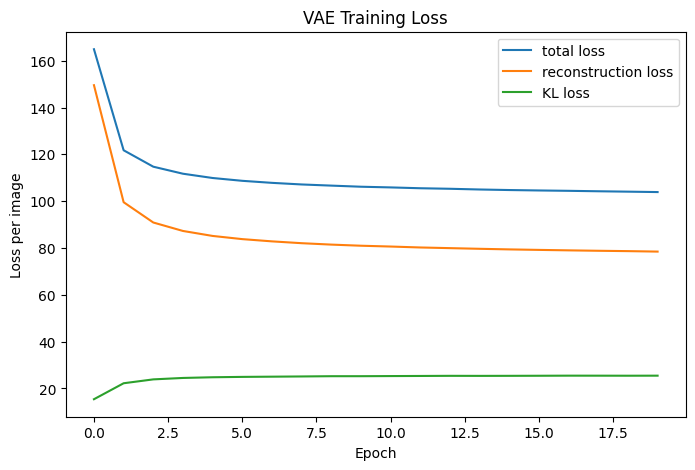

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="total loss")
plt.plot(history["recon_loss"], label="reconstruction loss")
plt.plot(history["kl_loss"], label="KL loss")
plt.xlabel("Epoch")
plt.ylabel("Loss per image")
plt.legend()
plt.title("VAE Training Loss")
plt.show()

## 9. 顯示重建結果

上排是原圖，下排是 VAE 重建圖。

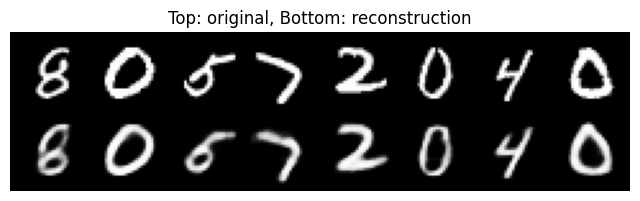

In [10]:
model.eval()
with torch.no_grad():
    sample_x, _ = next(iter(train_loader))
    sample_x = sample_x.to(device)
    x_recon, _, _ = model(sample_x)

comparison = torch.cat([
    sample_x[:8].cpu(),
    x_recon.view(-1, 1, 28, 28)[:8].cpu()
])

show_images(comparison, nrow=8, title="Top: original, Bottom: reconstruction")

## 10. 隨機生成新數字

這裡不是拿原圖重建，而是直接從標準常態分布抽 latent：

```python
z = torch.randn(64, latent_dim)
```

然後丟進 decoder 生成圖片。

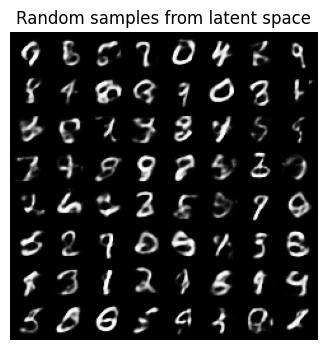

In [11]:
model.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    sample = model.decode(z)
    sample = sample.view(64, 1, 28, 28).cpu()

show_images(sample, nrow=8, title="Random samples from latent space")

## 11. 儲存與載入模型

In [12]:
torch.save(model.state_dict(), "mnist_vae.pth")
print("Model saved as mnist_vae.pth")

# 載入方式：
# loaded_model = VAE(latent_dim=latent_dim).to(device)
# loaded_model.load_state_dict(torch.load("mnist_vae.pth", map_location=device))
# loaded_model.eval()

Model saved as mnist_vae.pth


## 12. 重點整理

VAE 和普通 AutoEncoder 最大差異：

```text
普通 AE:
image → encoder → z → decoder → image

VAE:
image → encoder → mu, logvar → sample z → decoder → image
```

其中：

- `mu`：latent 分布的中心
- `logvar`：latent 分布的不確定性
- `z`：從這個分布抽樣出來的 latent
- `KL loss`：讓 latent 分布接近 `N(0, 1)`

所以 VAE 不是單純壓縮圖片，而是學會把圖片壓縮成一個「可以抽樣的機率空間」。

## 13. 自己輸入 latent 生成數字

這一格可以手動指定 latent vector，再直接丟進 decoder 生成圖片。

目前 `latent_dim = 20`，所以 `manual_z` 裡面要放 20 個數字。
你可以先從全 0 開始，再慢慢改其中幾個值觀察生成結果怎麼變。

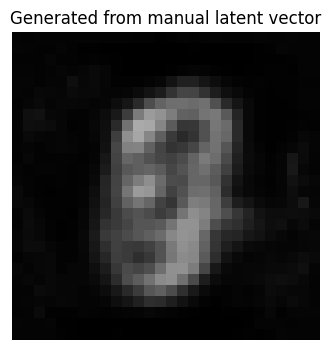

In [13]:
# 手動輸入 latent vector：數量必須等於 latent_dim
manual_z = [
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
]

if len(manual_z) != latent_dim:
    raise ValueError(f"manual_z 需要 {latent_dim} 個數字，但目前有 {len(manual_z)} 個。")

model.eval()
with torch.no_grad():
    z = torch.tensor([manual_z], dtype=torch.float32).to(device)
    generated = model.decode(z)
    generated = generated.view(1, 1, 28, 28).cpu()

show_images(generated, nrow=1, title="Generated from manual latent vector")